# Lab: Phân lớp

- MSSV: 22120222
- Họ và tên: Võ Văn Nam

## Yêu cầu bài tập

**Cách làm bài**


Bạn sẽ làm trực tiếp trên file notebook này; trong file, từ `TODO` để cho biết những phần mà bạn cần phải làm.

Bạn có thể thảo luận ý tưởng cũng như tham khảo các tài liệu, nhưng *code và bài làm phải là của bạn*. 

Nếu vi phạm thì sẽ bị 0 điểm cho bài tập này.

**Cách nộp bài**

Trước khi nộp bài, rerun lại notebook (`Kernel` -> `Restart & Run All`).

Sau đó, đặt tên notebook bằng `MSSV` của bạn (vd, nếu bạn có MSSV là 1234567 thì bạn đặt tên notebook là `1234567.ipynb`) và nộp ở link trên moodle.

**Nội dung bài tập**

Trong bài này, bạn sẽ cài đặt 2 thuật toán phân lớp: 
1. Cây quyết định (Decision tree)
2. Gaussian Naive Bayes

**Một số lưu ý**
1. Chỉ cần phát hiện có dấu hiện có sau chép code sẽ 0 điểm cả lab và có thể dẫn đến không điểm môn học
2. Sai format nộp bài sẽ bị trừ 20% số điểm
3. Trễ deadline 1 ngày sẽ bị trừ 40% số điểm. Sau 24h kể từ hạn nộp sẽ không nhận bất kì bài nộp bổ sung nào.
4. Các thắc mắc về bài tập, các bạn vui lòng liên hệ giáo viên qua email `ntthuhang0131@gmail.com` với tiêu đề `[Cơ sở trí tuệ nhân tạo - CQ2022/22 - Thắc mắc lab 03]`

### Thêm thư viện cần thiết

In [1]:
import matplotlib.pyplot as plt
from sklearn import datasets
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score

### Load dữ liệu Iris

In [2]:
from sklearn.model_selection import train_test_split
iris=datasets.load_iris()

X=iris.data
y=iris.target

#split dataset into training data and testing data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33, random_state=42)

## 1. Cây quyết định (Decision Tree)

## 1.1 Iterative Dichotomiser 3 (ID3) (2 đ)

### 1.1.1 Information Gain

Thông tin kỳ vọng (entropy):

$$Entropy=-\sum_{i}^{n}p_ilog_{2}(p_i)$$

Hàm entropy đạt giá trị nhỏ nhất nếu có một giá trị $p_i=1$, đạt giá trị lớn nhất nếu tất cả các $p_i$ bằng nhau. Những tính chất này của hàm entropy khiến nó được sử dụng trong việc đo độ hỗn loạn của một phép phân chia của ID3.

In [3]:
def entropy(counts, n_samples):
    """
    Parameters:
    -----------
    counts: shape (n_classes): list number of samples in each class
    n_samples: number of data samples
    
    -----------
    return entropy 
    """
    #TODO

    p = [] # list of probability of each class
    for count in counts:
        p.append(count / n_samples) # probability = number of samples in class / total number of samples
    
    res = 0
    for i in range(len(p)):
        res -= p[i] * np.log2(p[i])
            
    return res

In [4]:
def entropy_of_one_division(division): 
    """
    Returns entropy of a divided group of data
    Data may have multiple classes
    """
    n_samples = len(division)
    n_classes = set(division)
    
    counts=[]
    #count samples in each class then store it to list counts
    #TODO:
    
    for sample in n_classes:
        counts.append(list(division).count(sample))

    return entropy(counts,n_samples),n_samples


def get_entropy(y_predict, y):
    """
    Returns entropy of a split
    y_predict is the split decision by cutoff, True/Fasle
    """
    n = len(y)
    s_true, n_true = entropy_of_one_division(y[y_predict]) # left hand side entropy
    s_false, n_false = entropy_of_one_division(y[~y_predict]) # right hand side entropy
    s = n_true/n * s_true + n_false/n * s_false # overall entropy
    return s

Độ lợi thông tin phân lớp tập D theo thuộc tính A:
$$ Gain(A)=Entrophy(D)-Entrophy_{A}(D)$$

Trong ID3, tại mỗi node, thuộc tính được chọn được xác định dựa trên là thuộc tính khiến cho information gain đạt giá trị lớn nhất.

Các thuộc tính của tập Iris đều có giá trị liên tục. Do đó ta cần rời rạc hóa cho từng thuộc tính. Cách đơn giản là sử dụng một ngưỡng `cutoff` chia giá trị của dữ liệu trên mỗi thuộc tính sẽ làm 2 phần: `value<cutoff` và `value>=cutoff`.

Để tìm ngưỡng `cutoff` tốt nhất cho mỗi thuộc tính ta lần lượt thay `cutoff` bằng các giá trị của thuộc tính sau đó tính entropy, `cutoff` tốt nhất khi entropy bé nhất.  

### 1.1.2 Decision tree

In [5]:
class DecisionTreeClassifier:
    def __init__(self, tree=None, depth=0):
        '''Parameters:
        -----------------
        tree: decision tree
        depth: depth of decision tree after training'''
        
        self.depth = depth
        self.tree=tree
    def fit(self, X, y, node={}, depth=0):
        '''Parameter:
        -----------------
        X: training data
        y: label of training data
        ------------------
        return: node 
        
        node: each node represented by cutoff value and column index, value and children.
         - cutoff value is thresold where you divide your attribute
         - column index is your data attribute index
         - value of node is mean value of label indexes, 
           if a node is leaf all data samples will have same label
        
        Note that: we divide each attribute into 2 part => each node will have 2 children: left, right.
        '''
        
        #Stop conditions
        
        #if all value of y are the same 
        if np.all(y==y[0]):
            return {'val':y[0]}

        else: 
            col_idx, cutoff, entropy = self.find_best_split_of_all(X, y)    # find one split given an information gain 
            y_left = y[X[:, col_idx] < cutoff]
            y_right = y[X[:, col_idx] >= cutoff]
            node = {'index_col':col_idx,
                        'cutoff':cutoff,
                   'val':np.mean(y)}
            node['left'] = self.fit(X[X[:, col_idx] < cutoff], y_left, {}, depth+1)
            node['right'] = self.fit(X[X[:, col_idx] >= cutoff], y_right, {}, depth+1)
            self.depth += 1 
            self.tree = node
            return node
    
    def find_best_split_of_all(self, X, y):
        col_idx = None
        min_entropy = 1
        cutoff = None
        for i, col_data in enumerate(X.T):
            entropy, cur_cutoff = self.find_best_split(col_data, y)
            if entropy == 0:                   #best entropy
                return i, cur_cutoff, entropy
            elif entropy <= min_entropy:
                min_entropy = entropy
                col_idx = i
                cutoff = cur_cutoff
               
        return col_idx, cutoff, min_entropy
    
    def find_best_split(self, col_data, y):
        ''' Parameters:
        -------------
        col_data: data samples in column'''
         
        min_entropy = 10
        cutoff = None

        #Loop through col_data find cutoff where entropy is minimum
        #TODO
        for value in col_data:
            y_predict = np.array([True if data < value else False for data in col_data])
            entropy = get_entropy(y_predict, y) # Tính entropy để tìm ra giá trị cutoff tốt nhất
            if entropy < min_entropy:
                min_entropy = entropy
                cutoff = value
      
        return min_entropy, cutoff
                                               
    def predict(self, X):
        tree = self.tree
        pred = np.zeros(shape=len(X))
        for i, c in enumerate(X):
            pred[i] = self._predict(c)
        return pred
    
    def _predict(self, row):
        cur_layer = self.tree
        while cur_layer.get('cutoff'):
            if row[cur_layer['index_col']] < cur_layer['cutoff']:
                cur_layer = cur_layer['left']
            else:
                cur_layer = cur_layer['right']
        else:
            return cur_layer.get('val')

### 1.1.3 Classification on Iris Dataset

In [6]:
model = DecisionTreeClassifier()
tree = model.fit(X_train, y_train)
pred=model.predict(X_train)
print('Accuracy of your decision tree model on training data:', accuracy_score(y_train,pred))
pred=model.predict(X_test)
print('Accuracy of your decision tree model:', accuracy_score(y_test,pred))


Accuracy of your decision tree model on training data: 1.0
Accuracy of your decision tree model: 0.96


## 1.2 CART (Classification and Regression Trees) (2 đ)

Các bạn tự cài đặt lại thuật toán CART và test trên tập dữ liệu Iris (tham khảo cách trình bày ở `phần 1.1`)

### 1.2.1 Gini Impurity

Chỉ số Gini (Gini index/Gini impurity) được dùng để phân loại trong thuật toán CART. Gini Impurity thể hiện xác suất của việc phân loại sai khi ta chọn một phần tử ngẫu nhiên từ tập dữ liệu:

$$Gini Impurity=1-\sum_{i=1}^{n}(p_i)^2$$

Trong đó $p_i$ là xác suất của một phần tử được phân loại vào một lớp cụ thể.

- Gini Impurity bằng 0 khi tất cả các phần tử thuộc về một lớp.
- Gini Impurity gần bằng 1 khi mỗi lớp đều có một số lượng rất ít các phần tử.
- Gini Impurity bằng $1-1/n$ khi các phần tử được phân phối đều vào n lớp và mỗi lớp có xác suất là $1/n$.

Ví dụ, với 2 lớp, chỉ số Gini bằng $1-1/2=0.5$.

In [7]:
def gini_impurity(counts, n_samples):
    """
    Parameters:
    -----------
    counts: shape (n_classes): list number of samples in each class
    n_samples: number of data samples

    -----------
    return Gini impurity
    """
    p = [] # list of probability of each class
    for count in counts:
        p.append(count / n_samples) # probability = number of samples in class / total number of samples

    gini = 1
    for i in range(len(p)):
        gini -= p[i] ** 2

    return gini

In [8]:
def gini_of_one_division(division):
    """
    Returns Gini impurity of a divided group of data.
    Data may have multiple classes.
    """
    n_samples = len(division)
    n_classes = set(division)
    
    counts = []
    #count samples in each class then store it to list counts
    for sample in n_classes:
        counts.append(list(division).count(sample))
    
    return gini_impurity(counts, n_samples), n_samples


def get_gini(y_predict, y):
    """
    Returns Gini impurity of a split.
    y_predict is the split decision by cutoff, True/False
    """
    n = len(y)
    g_true, n_true = gini_of_one_division(y[y_predict])   # Left-hand side Gini
    g_false, n_false = gini_of_one_division(y[~y_predict])  # Right-hand side Gini
    g = n_true / n * g_true + n_false / n * g_false  # Weighted Gini
    return g

Gini index khi chia dữ liệu S theo thuộc tính A:
$$ G(S, A) = \sum_{i \in \text{Value}(A)}^{} \frac{\left| S_i \right|}{\left| S \right|}G(S_i) $$

Thuật toán CART phân loại dữ liệu bằng cách sử dụng Gini Impurity, đệ quy chia dữ liệu thành các tập con ngày càng nhỏ hơn, sao cho giảm thiểu mức độ hỗn tạp của dữ liệu trong các tập con.

Trong thuật toán CART, tại mỗi node, thuộc tính được chọn là thuộc tính khiến cho Gini index đạt giá trị nhỏ nhất.

Các thuộc tính của tập Iris đều có giá trị liên tục. Do đó ta cần rời rạc hóa cho từng thuộc tính. Cách đơn giản là sử dụng một ngưỡng `cutoff` chia giá trị của dữ liệu trên mỗi thuộc tính sẽ làm 2 phần: `value<cutoff` và `value>=cutoff`.

Để tìm ngưỡng `cutoff` tốt nhất cho mỗi thuộc tính ta lần lượt thay `cutoff` bằng các giá trị của thuộc tính sau đó tính Gini index, `cutoff` tốt nhất khi Gini index bé nhất.  

### 1.2.2 Decision tree

In [9]:
class CARTDecisionTreeClassifier:
    def __init__(self, tree=None, depth=0):
        '''Parameters:
        -----------------
        tree: decision tree
        depth: depth of decision tree after training'''
        self.depth = depth
        self.tree = tree

    def fit(self, X, y, node={}, depth=0):
        '''Parameter:
        -----------------
        X: training data
        y: label of training data
        ------------------
        return: node 

        node: each node represented by cutoff value and column index, value and children.
            - cutoff value is thresold where you divide your attribute
            - column index is your data attribute index
            - value of node is mean value of label indexes,
            if a node is leaf all data samples will have same label

        Note that: we divide each attribute into 2 part => each node will have 2 children: left, right.
        '''
        # Stop conditions

        # if all value of y are the same
        if np.all(y == y[0]):
            return {'val': y[0]}
        
        else:
            col_idx, cutoff, gini = self.find_best_split_of_all(X, y)   # find one split given an information gain
            y_left = y[X[:, col_idx] < cutoff]
            y_right = y[X[:, col_idx] >= cutoff]
            
            node = {'index_col': col_idx,
                    'cutoff': cutoff,
                    'val': np.mean(y)}
            node['left'] = self.fit(X[X[:, col_idx] < cutoff], y_left, {}, depth + 1)
            node['right'] = self.fit(X[X[:, col_idx] >= cutoff], y_right, {}, depth + 1)
            self.depth += 1
            self.tree = node
            return node

    def find_best_split_of_all(self, X, y):
        col_idx = None
        min_gini = 1  # Gini impurity is at most 1
        cutoff = None
        
        for i, col_data in enumerate(X.T):
            gini, cur_cutoff = self.find_best_split(col_data, y)
            if gini == 0:  # best gini
                return i, cur_cutoff, gini
            elif gini <= min_gini:
                min_gini = gini
                col_idx = i
                cutoff = cur_cutoff
                
        return col_idx, cutoff, min_gini

    def find_best_split(self, col_data, y):
        ''' Parameters:
        -------------
        col_data: data samples in column'''

        min_gini = 1 
        cutoff = None
        
        for value in col_data:
            y_predict = np.array([data < value for data in col_data])
            gini = get_gini(y_predict, y)
            if gini < min_gini:
                min_gini = gini
                cutoff = value
                
        return min_gini, cutoff

    def predict(self, X):
        tree = self.tree
        pred = np.zeros(shape=len(X))
        for i, c in enumerate(X):
            pred[i] = self._predict(c)
        return pred

    def _predict(self, row):
        cur_layer = self.tree
        while cur_layer.get('cutoff'):
            if row[cur_layer['index_col']] < cur_layer['cutoff']:
                cur_layer = cur_layer['left']
            else:
                cur_layer = cur_layer['right']
        else:
            return cur_layer.get('val')

### 1.2.3 Classification on Iris Dataset

In [10]:
cart_model = CARTDecisionTreeClassifier()
cart_tree = cart_model.fit(X_train, y_train)
train_pred = cart_model.predict(X_train)
test_pred = cart_model.predict(X_test)
print('Accuracy of CART decision tree model on training data:', accuracy_score(y_train, train_pred))
print('Accuracy of CART decision tree model:', accuracy_score(y_test, test_pred))

Accuracy of CART decision tree model on training data: 1.0
Accuracy of CART decision tree model: 0.98


## 1.3 Câu hỏi lý thuyết (2 đ)

*Đây là câu hỏi về lý thuyết có thể giúp các bạn buổi sung kiến thức cho các buổi phỏng vấn. Các bạn có thể tham khảo bất kì nguồn nào trừ ChatGPT và có thể thêm hình ảnh minh họa để có câu trả lời rõ ràng và dễ hiểu nhất. Và khi đã tham khảo phải liệt kê tài liệu tham khảo? Trường hợp phát hiện đạo văn bài làm sẽ nhận 0 điểm ngay lập tức.*

##### 1. So sánh Entropy, Gini Impurity và Variance Reduction trong Decision Tree. Khi nào nên sử dụng mỗi tiêu chí?

Câu trả lời:
`TODO`

Entropy:
- Entropy được sử dụng cho bài toán phân loại trong Decision Tree.
- Entropy được tính bằng công thức $Entropy=-\sum_{i=1}^{n}p_ilog_{2}(p_i)$.
- Entropy thể hiện mức độ hỗn loạn của dữ liệu trong tập.
- Entropy tính toán phức tạp hơn Gini Impurity vì sử dụng logarit.

Gini Impurity:
- Gini Impurity được sử dụng cho bài toán phân loại trong Decision Tree.
- Gini Impurity được tính bằng công thức $Gini=1-\sum_{i=1}^{n}(p_i)^2$.
- Gini Impurity thể hiện xác suất của phân loại sai khi ta chọn một phần tử ngẫu nhiên từ tập dữ liệu và phân loại nó.
- Vì không sử dụng logarit nên việc tính toán bằng Gini Impurity sẽ nhanh hơn Entropy.

Variance Reduction:
- Variance Reduction được sử dụng cho bài toán hồi quy trong Decision Tree.
- Variance được tính bằng công thức $Variance=\sigma^2=\frac{1}{n}\sum_{i=1}^{n} (x_i-\mu)^2$
- Variance Reduction tính toán độ giảm của phương sai (variance), qua đó ước tính độ tinh khiết của các nhánh trong cây quyết định khi xử lý các biến liên tục.

Trong trường hợp bài toán cây quyết định phân loại thì ta sử dụng Entropy hoặc Gini Impurity. Trong trường hợp bài toán cây quyết định hồi quy thì ta sử dụng Variance Impurity. Đối với cây phân loại, trong thực tế, sử dụng Entropy hay Gini Impurity đều cho kết quả rất giống nhau, có trường hợp sử dụng Entropy thì kết quả sẽ tốt hơn Gini Impurity một chút. Tuy nhiên, thời gian tính toán khi sử dụng Entropy lâu hơn, tính toán cũng phức tạp hơn Gain Impurity. 

##### 2. Overfitting trong Decision Tree là gì? Bạn có thể làm gì để giảm thiểu vấn đề này?
Câu trả lời:
`TODO`

Overfitting trong Decision Tree là hiện tượng học quá mức dữ liệu huấn luyện, dẫn đến việc cây trở nên quá phức tạp và tập trung quá nhiều vào các điểm dữ liệu cụ thể. Khi đó, cây quyết định sẽ có hiệu suất rất cao trên dữ liệu huấn luyện nhưng lại kém trên dữ liệu mới (dữ liệu kiểm tra) vì nó không khái quát hóa được trên dữ liệu mới.

Nguyên nhân gây ra overfitting trong Decision Tree:
- Do tạo cây quá sâu, cây trở nên quá phức tạp. Nếu cây phân chia dữ liệu quá nhiều, nó có thể "học" mọi chi tiết nhỏ của dữ liệu huấn luyện.
- Cây có thể quá tập trung vào các điểm dữ liệu cụ thể hoặc gây nhiễu trong dữ liệu.
- Quá coi trọng một số đặc trưng nhất định, dẫn đến thiên lệch tầm quan trọng của các đặc trưng.
- Không có các quy tắc dừng hợp lý, làm cây phát triển quá mức, khớp với dữ liệu huấn huyện nhưng không khái quát tốt trên dữ liệu mới.

Một số cách để làm giảm thiểu overfitting:
- Cắt tỉa (Pruning) là quá trình loại bỏ những nhánh của cây không đóng góp vào việc dự đoán, giúp đơn giản hóa mô hình, ngăn cây ghi nhớ nhiễu trong dữ liệu huấn luyện.
- Giới hạn chiều sâu tối đa của cây (Max Depth), giúp giảm độ phức tạp của cây và giảm overfit vào dữ liệu huấn luyện.
- Đặt một số lượng mẫu tối thiểu cho mỗi nút lá của cây (Minimum Samples per Leaf Node), đảm bảo mỗi nút lá chứa đủ dữ liệu để dự đoán
- Sử dụng các phương pháp Ensemble như Random Forest. Trong Random Forest, mỗi cây được huấn luyện trên một tập con ngẫu nhiên của dữ liệu huấn luyện. Dự đoán của cây quyết định được tổng hợp bằng cách tính trung bình kết quả từ tất cả các cây, cải thiện khả năng tổng quát.
- Cross-Validation, chia dữ liệu thành các tập huấn luyện và kiểm tra nhiều lần, huấn luyện mô hình trên các tập dữ liệu khác nhau và chọn ra mô hình tốt nhất.


##### 3. Decision Tree có phù hợp cho dữ liệu nhiều chiều hoặc dữ liệu không cân bằng không? Tại sao? 
Câu trả lời:
`TODO`

Decision Tree có thể sử dụng nhưng không quá phù hợp với dữ liệu nhiều chiều hoặc dữ liệu không cân bằng:

Đối với dữ liệu nhiều chiều, Decision Tree vẫn phù hợp nếu số chiều nhỏ. Nếu số chiều lớn Decision Tree sẽ trở nên phức tạp và dễ overfitting. Đối với trường hợp này, ta có thể làm giảm số chiều dữ liệu hoặc sử dụng các phương pháp ensemble như Random Forest. Random Forest có thể xử lý dữ liệu nhiều chiều và ít có khả năng bị overfitting hơn so với các cây quyết định riêng lẻ.

Đối với dữ liệu không cân bằng, Decision Tree có xu hướng thiên về lớp có số lượng mẫu lớn hơn, dẫn đến việc bỏ qua các lớp có số lượng mẫu nhỏ. Đối với trường hợp này, ta có thể cân bằng lại dữ liệu hoặc sử dụng các phương pháp ensemble như Gradient Boosting. Gradient Boosting có thể xây dựng các mô hình theo trình tự, mỗi mô hình mới tập trung sửa các lỗi do các mô hình trước đó gây ra.


##### 4. Nếu bạn có một Decision Tree quá lớn (deep tree), bạn sẽ làm gì để cải thiện khả năng tổng quát của nó?
Câu trả lời:
`TODO`

Như đã trình bày ở câu hỏi 2, khi Decision Tree quá lớn, cây sẽ trở nên rất phức tạp và rất dễ bị overfiting. Để cải thiện khả năng tổng quát của cây, ta có thể tăng số lượng dữ liệu huấn luyện, hoặc sử dụng các phương pháp như pruning, giới hạn chiều sâu tối đa của cây, minimum samples per leaf Node, ensemble methods hoặc cross-validation.


## 2. Định lý Bayes (4 đ)

Định lý Bayes được phát biểu dưới dạng toán học như sau:
$$\begin{equation}
P\left(A|B\right)= \dfrac{P\left(B|A\right)P\left(A\right)}{P\left(B\right)}
\end{equation}$$

Nếu ta coi $B$ là dữ liệu $\mathcal{D}$, các thông số cần ước tính $A$ là $w$, ta có:

$$ \begin{align}
    \underbrace{P(w|\mathcal{D})}_{Posterior}= \dfrac{1}{\underbrace{P(\mathcal{D})}_{Normalization}} \overbrace{P(\mathcal{D}|w)}^{\text{Likelihood}} \overbrace{P(w)}^{Prior}
    \end{align}
$$

#### Naive Bayes
Để giúp cho việc tính toán được đơn giản, người ta thường giả sử một cách đơn giản nhất rằng các thành phần của biến ngẫu nhiên $D$ (hay các thuộc tính của dữ liệu $D$) là độc lập với nhau, nếu biết $w$. Tức là:
$$P(\mathcal{D}|w)=\prod _{i=1}^{d}P(x_i|w)$$

$d$: số lượng thuộc tính


## 2.1 Probability Density Function

In [11]:
class pdf:
    def __init__(self,hist=None):
        '''
        A probability density function represented by a histogram
        
        hist: shape (n,1), n: number of hypotheses
        hypo: hypothesis (simply understand as label)
        hist[hypo]=P(hypo)
        '''
        self.hist = hist
        
    #virtual function
    def likelihood(self, data, hypo):
        '''Paramters:
        data: new data record 
        hypo: hypothesis (simply understand as label)
        ---------
        return P(data/hypo)
        ''' 
        raise Exception()
            
    #update histogram for new data 
    def update(self, data):
        ''' 
        P(hypo/data)=P(data/hypo)*P(hypo)*(1/P(data))
        '''
        
        #Likelihood * Prior 
        #TODO
        for hypo in self.hist.keys():
            self.hist[hypo] = self.hist[hypo] * self.likelihood(data, hypo)
       
            
        #Normalization
        
        #TODO: s=P(data)
        #s=?
        s = sum(self.hist.values())
        
        for hypo in self.hist.keys():
            self.hist[hypo] = self.hist[hypo]/s
        
    def plot_pdf(self):
        #plot Histogram
        #TODO
        plt.bar(self.hist.keys(), self.hist.values(), color='skyblue')
        plt.title('Histogram of Hypotheses')
        plt.xlabel('Hypothesis')
        plt.ylabel('Probability')
        plt.show()
      
    
    def maxHypo(self):
        #find the hypothesis with maximum probability from hist
        #TODO
        max_prob = max(self.hist.values())
        for hypo in self.hist.keys():
            if self.hist[hypo] == max_prob:
                return hypo
        return None

        
        



## 2.2 Classification on Iris Dataset

#### Gaussian Naive Bayes

- Naive Bayes có thể được mở rộng cho dữ liệu với các thuộc tính có giá trị là số thực, phổ biến nhất bằng cách sử dụng phân phối chuẩn (Gaussian distribution).

- Phần mở rộng này được gọi là Gaussian Naive Bayes. Các hàm khác có thể được sử dụng để ước tính phân phối dữ liệu, nhưng Gaussian (hoặc phân phối chuẩn) là dễ nhất để làm việc vì chỉ cần ước tính giá trị trung bình và độ lệch chuẩn từ dữ liệu huấn luyện.

#### Định nghĩa hàm Gauss 

$$ f\left(x;\mu,\sigma \right)= \dfrac{1}{\sigma \sqrt{2\pi}} 
\exp \left({-\dfrac{\left(x-\mu\right)^2}{2 \sigma^2}}\right) $$

In [12]:
def Gauss(std,mean,x):
    #Calculate the Gaussian probability distribution function for x
    #TODO 
    f = 1/(std*np.sqrt(2*np.pi))*np.exp(-((x-mean)**2)/(2*std**2))
    return f
    

In [13]:
class NBGaussian(pdf):
    def __init__(self, hist=None, std=None, mean=None):
        '''Parameters:
        
        '''
        pdf.__init__(self, hist)
        self.std=std
        self.mean=mean
    def likelihood(self,data, hypo):
        '''
        Returns: P(data/hypo)
        -----------------
        Naive bayes:
            Atributes are assumed to be conditionally independent given the class value.
        '''
    
        std=self.std[hypo]
        mean=self.mean[hypo]
        res=1
        #TODO
        #res=res*P(xi/hypo)
        for i in range(len(data)):
            res = res * Gauss(std[i], mean[i], data[i])

        return res
    def fit(self, X,y):
        """Parameters:
        X: training data
        y: labels of training data
        """
        n=len(X)
        #number of iris species
        #TODO
        n_species = len(set(y)) # number of unique labels - iris species
        
        hist={}
        mean={}
        std={}
        
        #separate  dataset into rows by class
        for hypo in range(0,n_species):
            #TODO rows=?
            rows = [X[i] for i in range(n) if y[i] == hypo]
            
            #histogram for each hypo
            #TODO probability=?
            probability = len(rows)/n
            hist[hypo]=probability
            
            #Gaussian naive bayes each hypothesis represented by its mean and standard derivation
            '''mean and standard derivation should be calculated for each column (or each attribute)'''
            #TODO mean[hypo]=?, std[hypo]=?
            mean[hypo] = np.mean(rows, axis=0)
            std[hypo] = np.std(rows, axis=0)
            
        self.mean=mean
        self.std=std
        self.hist=hist
   
    def _predict(self, data, plot=False):
        """
        Predict label for only 1 data record
        ------------
        Parameters:
        data: new data record
        plot: True: draw histogram after update new record
        -----------
        return: label of data
        """
        model=NBGaussian(hist=self.hist.copy(),std=self.std.copy(), mean=self.mean.copy())
        model.update(data)
        if (plot): model.plot_pdf()
        return model.maxHypo()
    
    def predict(self, data):
        """Parameters:
        Data: test data
        ----------
        return labels of test data"""
        
        pred=[]
        for x in data:
            pred.append(self._predict(x))
        return pred

#### Vẽ histogram of training data

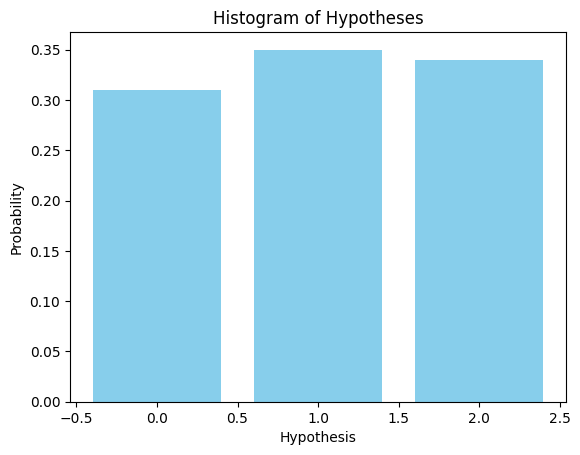

In [14]:
model_1=NBGaussian()
model_1.fit(X_train, y_train)
model_1.plot_pdf()

Nhận xét chart: `TODO`

- Xác suất của 3 lớp xấp xỉ với nhau, gần bằng 1/3, mô hình không bị lệch về lớp nào, dữ liệu giữa 3 lớp khá đồng đều.


#### Test

Label of X_test[10]:  2
Our histogram after update X_test[10]: 


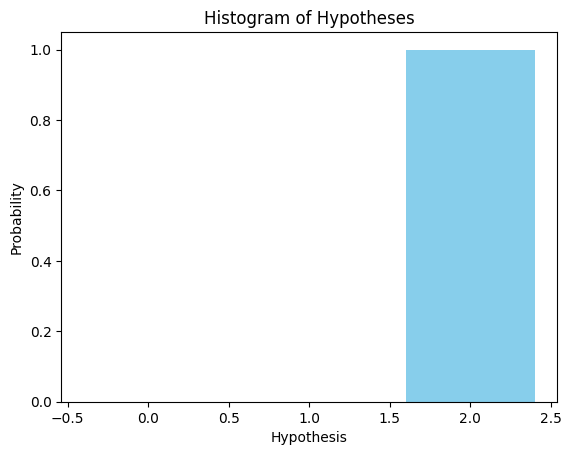

2

In [15]:
#label of y_test[10]
print('Label of X_test[10]: ', y_test[10])
#update model and show histogram with X_test[10]:

print('Our histogram after update X_test[10]: ')
model_1._predict(X_test[10],plot=True)


#### Đánh giá hiệu suất mô hình Gaussian Naive Bayes

In [16]:
pred=model_1.predict(X_test)
print('Accuracy of your Gaussian Naive Bayes model:', accuracy_score(y_test,pred))

Accuracy of your Gaussian Naive Bayes model: 0.96


## 2.3 Một số câu hỏi lí thuyết

*Đây là câu hỏi về lý thuyết có thể giúp các bạn buổi sung kiến thức cho các buổi phỏng vấn. Các bạn có thể tham khảo bất kì nguồn nào trừ ChatGPT và có thể thêm hình ảnh minh họa để có câu trả lời rõ ràng và dễ hiểu nhất. Và khi đã tham khảo phải liệt kê tài liệu tham khảo? Trường hợp phát hiện đạo văn bài làm sẽ nhận 0 điểm ngay lập tức.*

##### 1. Trường hợp sử dụng Gaussian Naive Bayes? Nêu chí tiết và cho 3 ứng dụng cụ thể (nêu rõ: input là gì? output là gì? mục tiêu sử dụng?)?

Câu trả lời:
`TODO`

Gaussian Naive Bayes (GNB) được sử dụng trong các bài toán phân loại khi dữ liệu có thành phần là các biến liên tục, giả thiết rằng các đặc trưng này tuân theo phân phối chuẩn (Gaussian distribution) và các chiều của dữ liệu độc lập với nhau.

3 ứng dụng cụ thể sử dụng Gaussian Naive Bayes:

1. Phân loại loài hoa (trên tập dữ liệu Iris trong lab này)
- Input: Các đặc trưng như chiều dài, chiều rộng cánh hoa, nhụy hoa, v.v.
- Output: Loại hoa (ví dụ: Iris-setosa, Iris-versicolor, Iris-virginica).
- Mục tiêu sử dụng: Xác định loài hoa dựa trên các đặc điểm hình thái.

2. Phân loại thư rác
Input: Các đặc trưng như tần suất của các từ khóa trong email, độ dài email, v.v.
Output: Nhãn phân loại thư là Spam hoặc Không Spam.
Mục tiêu sử dụng: Phân loại email thành thư rác hoặc không phải thư rác dựa trên nội dung và đặc điểm của email.

3. Phân loại đánh giá 
- Input: Các bình luận, đánh giá nhận xét sản phẩm hoặc phản hồi từ khách hàng.
- Output: Nhãn phân loại đánh giá là đánh giá tích cực hay đánh giá tiêu cực.
- Mục tiêu sử dụng: Phân tích đánh giá của người dùng dựa trên các đánh giá sản phẩm hoặc phản hồi khách hàng.

##### 2. Có điều kiện bắt buộc nào của dữ liệu đầu vào khi sử dụng Gaussian Naive Bayes không?

Câu trả lời:
`TODO`

Các điều kiện của dữ liệu đầu vào khi sử dụng Gaussian Naive Bayes:
- Dữ liệu đầu vào là số thực, các thành phần là các biến liên tục.
- Dữ liệu đầu vào của các đặc trưng tuân theo phân phối chuẩn Gaussian. Nếu dữ liệu phối phối lệch quá nhiều so với phân phối chuẩn, mô hình có thể thiếu chính xác.
- Các đặc trưng, chiều của dữ liệu là độc lập với nhau (giả thiết). Nếu các đặc trưng có tương quan mạnh với nhau, mô hình có thể hoạt động không tốt vì chúng không độc lập.

##### 3. Tại sao Naive Bayes thường được sử dụng trong các bài toán phân loại văn bản (Text Classification)?
Câu trả lời : `TODO`

Naive Bayes thường được sử dụng trong các bài toán phân loại văn bản vì có thời gian training và test rất nhanh, dễ huấn luyện do giả thiết các thành phần là độc lập nếu biết class.

Ngoài ra, Naive Bayes còn dễ dàng tính xác suất có điều kiện giữa từ và nhãn lớp dựa trên tần suất từ xuất hiện, phù hợp với đặc trưng của dữ liệu văn bản.

## Tài liệu tham khảo

**1. "34. Decision Trees (1): ID3 - Machine Learning cơ bản"**
- Đường dẫn: https://machinelearningcoban.com/2018/01/14/id3/

**2. "CART (Classification And Regression Tree) in Machine Learning - GeeksforGeeks"**
- Đường dẫn: https://www.geeksforgeeks.org/cart-classification-and-regression-tree-in-machine-learning/

**3. "Decision Tree và ý nghĩa của các chỉ số Gini Impurity và Entropy"**
- Đường dẫn: https://blog.vietnamlab.vn/decistion-tree/

**4. "Decision Trees: Gini vs Entropy"**
- Đường dẫn: https://quantdare.com/decision-trees-gini-vs-entropy/

**5. "Decision Tree Algorithm, Explained"**
- Đường dẫn: https://www.kdnuggets.com/2020/01/decision-tree-algorithm-explained.html

**6. "Decision Trees in Machine Learning (with Python Examples)"**
- Đường dẫn: https://www.jcchouinard.com/decision-trees-in-machine-learning/

**7. "Overfitting in Decision Tree Models"**
- Đường dẫn: https://www.geeksforgeeks.org/overfitting-in-decision-tree-models/

**8. "Understanding Tree-Based Models: A Simple Guide"**
- Đường dẫn: https://thedatascientist.com/understanding-tree-based-models-a-simple-guide/

**9. "32. Naive Bayes Classifier - Machine Learning cơ bản"**
- Đường dẫn: https://machinelearningcoban.com/2017/08/08/nbc/

**10. "Gaussian Naive Bayes - GeeksforGeeks"**
- Đường dẫn: https://www.geeksforgeeks.org/gaussian-naive-bayes/